# Human Activity Recognition using Bidirectional LSTM

* Developed a deep learning model to classify six human activities using smartphone acceleromrter and gyroscope data.

* Implemented a Bidirectinal LSTM architecture to learn temporal patterns from sensor sequences.

* Achieved high classification accuracy on the UCI HAR dataset.

* Visualized result using confusion matrix and classification report.

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

In [2]:
DATASET_PATH = "/content/human+activity+recognition+using+smartphones.zip"


In [3]:
import zipfile
import os
import numpy as np

def load_X(path):
    return np.loadtxt(path)

def load_y(path):
    # Labels are 1-6 in dataset, convert to 0-5
    return np.loadtxt(path).astype(int) - 1

EXTRACT_DIR = "./UCI_HAR_Dataset"
FINAL_DATA_DIR = os.path.join(EXTRACT_DIR, "UCI HAR Dataset") # Expected final location of actual data

if not os.path.exists(FINAL_DATA_DIR):
    print(f"Extracting dataset from {DATASET_PATH} to {EXTRACT_DIR}...")
    with zipfile.ZipFile(DATASET_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print("First-level extraction complete.")

    # Check if a nested zip file exists and extract it
    nested_zip_path = os.path.join(EXTRACT_DIR, "UCI HAR Dataset.zip")
    if os.path.exists(nested_zip_path):
        print(f"Found nested zip: {nested_zip_path}. Extracting to {EXTRACT_DIR}...")
        with zipfile.ZipFile(nested_zip_path, 'r') as nested_zip_ref:
            nested_zip_ref.extractall(EXTRACT_DIR)
        print("Nested extraction complete.")
        # After extracting, the 'UCI HAR Dataset' folder should now be directly in EXTRACT_DIR
    else:
        print(f"No nested 'UCI HAR Dataset.zip' found at {nested_zip_path}.")
        print("Please verify the contents of your zip file and its extraction structure.")
else:
    print(f"Dataset already extracted to {FINAL_DATA_DIR}.")

# Set the effective_dataset_root directly to where the actual data should reside
effective_dataset_root = FINAL_DATA_DIR

# Verify that the expected 'train' directory exists under effective_dataset_root
if not os.path.exists(os.path.join(effective_dataset_root, "train")):
    print(f"Error: Expected 'train' directory not found under {effective_dataset_root}.")
    print(f"Current contents of {effective_dataset_root}: {os.listdir(effective_dataset_root) if os.path.exists(effective_dataset_root) else 'Directory does not exist'}")
    raise FileNotFoundError(f"Cannot find 'train' directory in {effective_dataset_root}. Check extraction path.")

print(f"Attempting to load data from calculated effective_dataset_root: {effective_dataset_root}")

X_train = load_X(os.path.join(effective_dataset_root, "train", "X_train.txt"))
X_test = load_X(os.path.join(effective_dataset_root, "test", "X_test.txt"))

y_train = load_y(os.path.join(effective_dataset_root, "train", "y_train.txt"))
y_test = load_y(os.path.join(effective_dataset_root, "test", "y_test.txt"))

Extracting dataset from /content/human+activity+recognition+using+smartphones.zip to ./UCI_HAR_Dataset...
First-level extraction complete.
Found nested zip: ./UCI_HAR_Dataset/UCI HAR Dataset.zip. Extracting to ./UCI_HAR_Dataset...
Nested extraction complete.
Attempting to load data from calculated effective_dataset_root: ./UCI_HAR_Dataset/UCI HAR Dataset


In [4]:
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (7352, 561)
X_test shape: (2947, 561)
y_train shape: (7352,)
y_test shape: (2947,)


# Reshape Data

In [5]:
TIME_STEP = 51
N_FEATURES = 11

X_train = X_train.reshape(-1, TIME_STEP, N_FEATURES)
X_test = X_test.reshape(-1, TIME_STEP, N_FEATURES)

print('Reshape X_train:', X_train.shape)
print('Reshape X_test:', X_test.shape)

Reshape X_train: (7352, 51, 11)
Reshape X_test: (2947, 51, 11)


# One-Hot Encode Labels


In [6]:
NUM_CLASS =6
y_train = to_categorical(y_train,NUM_CLASS)
y_test = to_categorical(y_test,NUM_CLASS)

print('One-Hot labels shape:',y_train.shape)

One-Hot labels shape: (7352, 6)


# Class Names

In [7]:
class_names =[
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# Build Bidirectional LSTM Model

In [8]:
model = Sequential()
model.add(Bidirectional(LSTM(128, return_sequences=True), input_shape=(TIME_STEP, N_FEATURES)))
model.add(Dropout(0.3))

model.add(Bidirectional(LSTM(64, return_sequences=False))) # Changed to return_sequences=False
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dense(NUM_CLASS, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 51, 256)        │       143,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 51, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,358 (1.21 MB)

 Trainable params: 316,358 (1.21 MB)

 Non-trainable params: 0 (0.00 B)

# Call backs

In [9]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        'best_har_bilstm.keras',
        save_best_only=True
    )
]


# Train Model

In [10]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 221ms/step - accuracy: 0.4795 - loss: 1.0897 - val_accuracy: 0.7016 - val_loss: 0.7049
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 212ms/step - accuracy: 0.7075 - loss: 0.6288 - val_accuracy: 0.7886 - val_loss: 0.4868
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 206ms/step - accuracy: 0.7871 - loss: 0.4837 - val_accuracy: 0.7308 - val_loss: 0.5940
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 199ms/step - accuracy: 0.8405 - loss: 0.3702 - val_accuracy: 0.8430 - val_loss: 0.3691
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 211ms/step - accuracy: 0.8830 - loss: 0.2854 - val_accuracy: 0.8804 - val_loss: 0.2760
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 208ms/step - accuracy: 0.8932 - loss: 0.2517 - val_accuracy: 0.8892 - val_loss: 0.2753
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 200ms/step - accuracy: 0.9100 - loss: 0.2189 - val_accuracy: 0.9082 - val_loss: 0.2518
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 214ms/step - accuracy: 0.9162 - loss: 0.2045 - val_accu

# Plot Training Curves

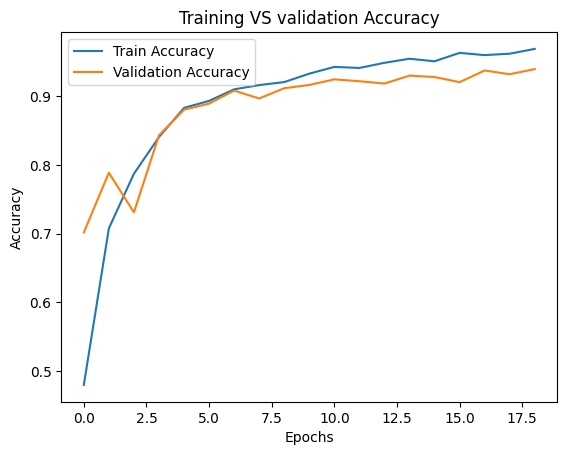

In [11]:
# Accuracy
plt.figure()
plt.plot(history.history['accuracy'],label = 'Train Accuracy')
plt.plot(history.history['val_accuracy'],label = 'Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training VS validation Accuracy')
plt.show()

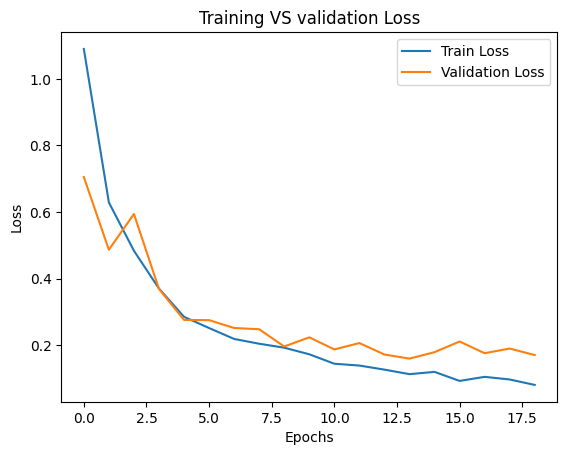

In [12]:
# Loss
plt.figure()
plt.plot(history.history['loss'], label = 'Train Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training VS validation Loss')
plt.show()

# Evaluate Model

In [13]:
test_loss, test_accuracy = model.evaluate(X_test, y_test,verbose = 0)
print('Test Loss:', test_loss)
print('Test Accuracy:', test_accuracy)

Test Loss: 0.29468774795532227
Test Accuracy: 0.9029521346092224


# Predictions

In [14]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step


# Classification Report

In [15]:
print(classification_report(
    np.argmax(y_test, axis=1),
    y_pred,
    target_names = class_names
))

                    precision    recall  f1-score   support

           WALKING       0.89      0.97      0.93       496
  WALKING_UPSTAIRS       0.94      0.86      0.89       471
WALKING_DOWNSTAIRS       0.87      0.87      0.87       420
           SITTING       0.87      0.82      0.85       491
          STANDING       0.85      0.89      0.87       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.90      2947
         macro avg       0.90      0.90      0.90      2947
      weighted avg       0.90      0.90      0.90      2947



# Confussion Matrix

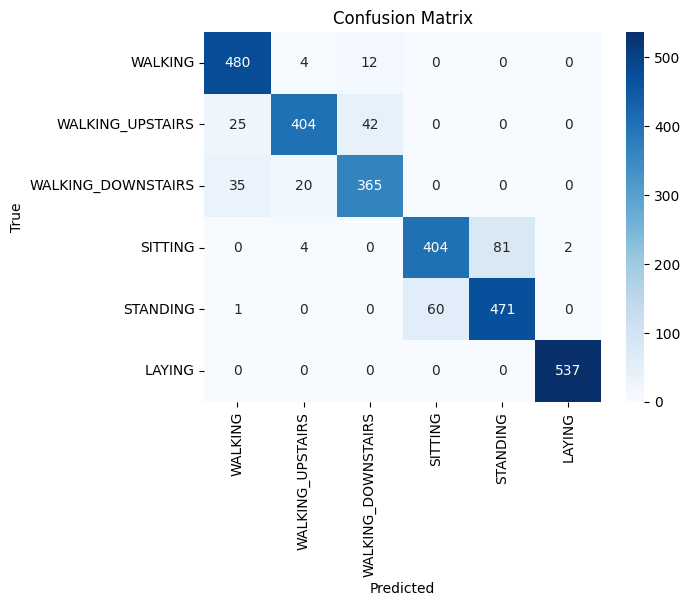

In [16]:
cm = confusion_matrix(np.argmax(y_test, axis=1), y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Predict on a Single Sample

In [17]:
sample = X_test[0:100]
pred = model.predict(sample)
pred_class = np.argmax(pred, axis=1)

print('Predicted Activity:', class_names[pred_class[0]])
print('Actual Activity:', class_names[np.argmax(y_test[0])])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted Activity: STANDING
Actual Activity: STANDING
